In [37]:
# Classification models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, precision_score


In [38]:
# Load the dataset
df = pd.read_csv('/run/media/awongo-fahadi-rashid/AFRAH/Projects/Recess Term/Lectures/Day11/ecommerce_bigdata.csv')
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [39]:
df_copy = df.copy()
# Drop unnecessary columns
df_copy = df_copy.drop(columns=['TransactionID', 'Date'])
df_copy.head()

,Region,ProductCategory,CustomerType,Sales,Profit
0,Eastern,Electronics,Wholesale,4924,359.44
1,Central,Electronics,Retail,3283,944.32
2,Northern,Food,Online,4049,967.10
3,Western,Household Products,Online,4331,434.57
4,Western,Household Products,Retail,3283,340.48


In [40]:
# Create a dictionary to hold all column mappings for reference later
encoding_mappings = {}

# Identify categorical columns in the DataFrame
categorical_cols = df_copy.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    # 1. Convert the column to a pandas 'category' type
    df_copy[col] = df_copy[col].astype('category')
    
    # 2. Extract the categories to create our map tracker
    mapping = {category: index for index, category in enumerate(df_copy[col].cat.categories)}
    encoding_mappings[col] = mapping
    
    # 3. Permanently replace the text labels with the integer codes
    df_copy[col] = df_copy[col].cat.codes
    
    # 4. Print the clean structural breakdown for this column
    print(f"--- Encoded Column: {col} ---")
    print(mapping)
    print()
df_copy.head(10)

--- Encoded Column: Region ---
{'Central': 0, 'Eastern': 1, 'Northern': 2, 'Western': 3}

--- Encoded Column: ProductCategory ---
{'Beverages': 0, 'Clothing': 1, 'Electronics': 2, 'Food': 3, 'Household Products': 4}

--- Encoded Column: CustomerType ---
{'Online': 0, 'Retail': 1, 'Wholesale': 2}



,Region,ProductCategory,CustomerType,Sales,Profit
0,1,2,2,4924,359.44
1,0,2,1,3283,944.32
2,2,3,0,4049,967.10
3,3,4,0,4331,434.57
4,3,4,1,3283,340.48
5,2,1,1,1088,153.77
6,0,0,1,4158,958.09
7,3,4,2,1090,302.28
8,3,4,1,302,54.12
9,3,0,2,4821,1094.26


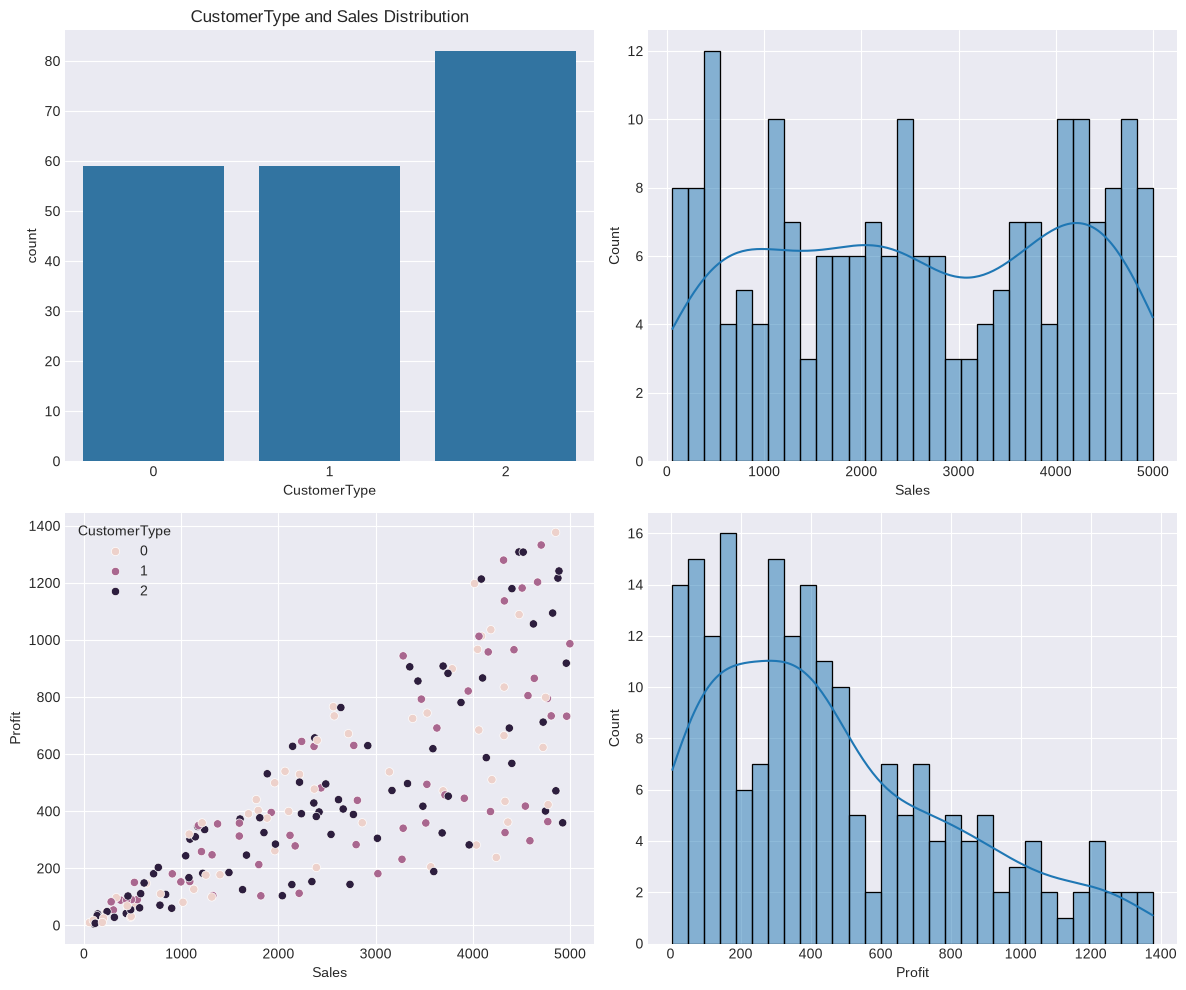

In [55]:
# Visualize the distribution of the target variable
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(2,2, figsize=(12, 10))
ax[0,0].set_title('CustomerType and Sales Distribution')
sns.countplot(data=df_copy, x='CustomerType', ax=ax[0,0])
sns.histplot(data=df_copy, x='Sales', ax=ax[0,1], bins=30, kde=True)
sns.scatterplot(data=df_copy, x='Sales', y='Profit', hue='CustomerType', ax=ax[1,0])
sns.histplot(data=df_copy, x='Profit', ax=ax[1,1], bins=30, kde=True)
plt.tight_layout()

In [56]:
# Raandom Forest Classifier to predict CustomerType based on other features
# Split the data into features and target variable
X = df_copy.drop(columns=['CustomerType'])
y = df_copy['CustomerType']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# METRICS
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")

Random Forest Classifier Accuracy: 0.1750
Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.20      0.18        10
           1       0.12      0.20      0.15        10
           2       0.27      0.15      0.19        20

    accuracy                           0.17        40
   macro avg       0.19      0.18      0.17        40
weighted avg       0.21      0.17      0.18        40

Recall: 0.1750
Precision: 0.2074
F1-Score: 0.1793


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Create a safe working copy of your exact 5 columns
df_rf = df_copy.copy()

# 2. Add an Engineered Ratio Feature
# This highlights the margin difference between Wholesale (bulk/low margin) and Online (high margin)
df_rf['ProfitMargin'] = df_rf['Profit'] / (df_rf['Sales'] + 0.001)

# 3. Separate your Features (X) and your Target (y)
# X will automatically grab: Region, ProductCategory, Sales, Profit, and ProfitMargin
X = df_rf.drop(columns=['CustomerType'])
y = df_rf['CustomerType']

# 4. Split with Stratification 
# This forces the training and testing sets to have equal splits of classes 0, 1, and 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Initialize and Train the Random Forest Classifier
# We limit max_depth so it doesn't over-optimize on the overlapping Sales rows
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    max_depth=4, 
    class_weight='balanced', 
    random_state=42
)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("       UPDATED RANDOM FOREST CLASSIFIER")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}\n")
print("Detailed Breakdowns:")
print(classification_report(y_test, y_pred, zero_division=0))


       UPDATED RANDOM FOREST CLASSIFIER
Accuracy:  0.3750
Precision: 0.3982
Recall:    0.3750
F1-Score:  0.3747

Detailed Breakdowns:
              precision    recall  f1-score   support

           0       0.38      0.50      0.43        12
           1       0.29      0.33      0.31        12
           2       0.50      0.31      0.38        16

    accuracy                           0.38        40
   macro avg       0.39      0.38      0.37        40
weighted avg       0.40      0.38      0.37        40

